# **AIN 214 - PA4 - FALL 2024**




**Student Number** : 2210765048

**Name Surname**   : Büşra Şerbetci


BELOW MD CELLS CONTAIN THE QUESTIONS YOU ARE ASKED TO IMPLEMENT WITHIN THE CONTEXT OF THIS HW. PLEASE FILL IN THE CELLS FOR THE ANSWERS RIGHT BELOW THE MD CELL OF THE QUESTION. YOU CAN ADD AS MANY CELLS AS YOU WANT, BE IT CODE OR MD, SO LONG AS YOU PROVIDE UNDERSTANDABLE AND TRACEABLE REPORTING. PLEASE ADD COMMENTS ON YOUR CODES. ALSO, FILL IN MD CELLS WHERE YOU ARE ASKED TO COMMENT ON YOUR RESULTS OR EXPLAIN YOUR REASONING. ALSO, PLEASE DO NOT HESITATE TO USE THEM FOR YOUR OWN REPORTING PURPOSES. PLEASE KEEP IN MIND THAT, REPORTING IS A KEY STEP IN DATA SCIENCE.

**Deadline: 13.12.2024 (23:59:59)**

**Submission:** Submit your Jupyter Notebooks via https://submit.cs.hacettepe.edu.tr/

<font color='red'> **!!! PLEASE RUN YOUR CODE.   THE OUTPUT OF YOUR CODE MUST BE VISIBLE. DO NOT DELETE OR HIDE THE OUTPUT.**</font>



---


# **Building kNN and Logistic Regression Classifiers**

---
**Dataset Path:** "Data/stroke.csv"
---

We will deal with the stroke dataset. The dataset contains demographic and health-related data to predict whether a patient is likely to have a stroke.

**Features:**


* id: Unique identifier (can be ignored for modeling).
* gender: Gender of the patient (categorical).
* age: Age of the patient (numerical).
* hypertension: Whether the patient has hypertension (0 = No, 1 = Yes).
* heart_disease: Whether the patient has heart disease (0 = No, 1 = Yes).
* ever_married: Marital status (categorical).
* work_type: Type of work (categorical).
* Residence_type: Rural or Urban (categorical).
* avg_glucose_level: Average glucose level (numerical).
* bmi: Body Mass Index (numerical).
* smoking_status: Smoking habits (categorical).
* stroke: Target variable (1 = Stroke, 0 = No Stroke).

# **Necessary Imports**

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve, roc_curve, auc, accuracy_score, precision_score, recall_score, f1_score

## 1.1. Explaratory Data Analysis (20 Pts)

* Load the dataset
* Check and Handle Missing Values

  * Identify columns with missing values.
  * Replace missing values using suitable methods (mean or median imputation).

* Check and Handle Outliers

  * Detect outliers in numerical features
  * Handle outliers appropriately

* Convert categorical variables into numerical values.
* Perform data normalization



In [69]:
# Load the dataset
stroke_data = pd.read_csv("Data/stroke.csv")

#Check and Handle Missing Values
print(stroke_data.isnull().sum())

#Replace missing values in 'bmi' column using median imputation
stroke_data['bmi'].fillna(stroke_data['bmi'].median(), inplace=True)

#Check if there are any missing values after imputation
print(stroke_data.isnull().sum())

#Detect outliers using IQR for numerical features: 'age', 'avg_glucose_level', 'bmi'
numerical_features = ['age', 'avg_glucose_level', 'bmi']

#Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = stroke_data[numerical_features].quantile(0.25)
Q3 = stroke_data[numerical_features].quantile(0.75)

#Calculate IQR (Interquartile Range)
IQR = Q3 - Q1

#Identify outliers as values outside 1.5*IQR from Q1 and Q3
outliers = ((stroke_data[numerical_features] < (Q1 - 1.5 * IQR)) | 
            (stroke_data[numerical_features] > (Q3 + 1.5 * IQR)))

#Display the number of outliers in each feature
print("\nOutliers (True = Outlier, False = Not Outlier):")
print(outliers.sum())

#Handle outliers: Replace outliers with the median of the respective column
for feature in numerical_features:
    stroke_data[feature] = np.where(outliers[feature], stroke_data[feature].median(), stroke_data[feature])

#Convert categorical variables (gender, ever_married, work_type, Residence_type, smoking_status) using Label Encoding
categorical_features = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

#Mapping categorical columns to numeric values
stroke_data['gender'] = stroke_data['gender'].map({'Male': 1, 'Female': 0})
stroke_data['ever_married'] = stroke_data['ever_married'].map({'Yes': 1, 'No': 0})
stroke_data['work_type'] = stroke_data['work_type'].map({'Private': 0, 'Self-employed': 1, 'Govt_job': 2, 'children': 3, 'Never_worked': 4})
stroke_data['Residence_type'] = stroke_data['Residence_type'].map({'Urban': 1, 'Rural': 0})
stroke_data['smoking_status'] = stroke_data['smoking_status'].map({'formerly smoked': 0, 'never smoked': 1, 'smokes': 2, 'Unknown': 3})

#Normalize numerical features using StandardScaler
scaler = StandardScaler()
stroke_data[numerical_features] = scaler.fit_transform(stroke_data[numerical_features])

#Display the final dataset after processing
print("\nProcessed Data:")
print(stroke_data.head())


id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64
id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

Outliers (True = Outlier, False = Not Outlier):
age                    0
avg_glucose_level    627
bmi                  126
dtype: int64

Processed Data:
      id  gender       age  hypertension  heart_disease  ever_married  \
0   9046     1.0  1.051434             0              1             1   
1  51676     0.0  0.786070             0              0             1   
2  31112     1.0  1.62639

## 1.2. Data Visualization (10 Pts)

* Visualize the distribution of numerical features
* Analyze the relationship between categorical features (e.g., gender, work_type) and the target variable (stroke).
* Plot a correlation heatmap to analyze their relationships.
* Comment on any findings

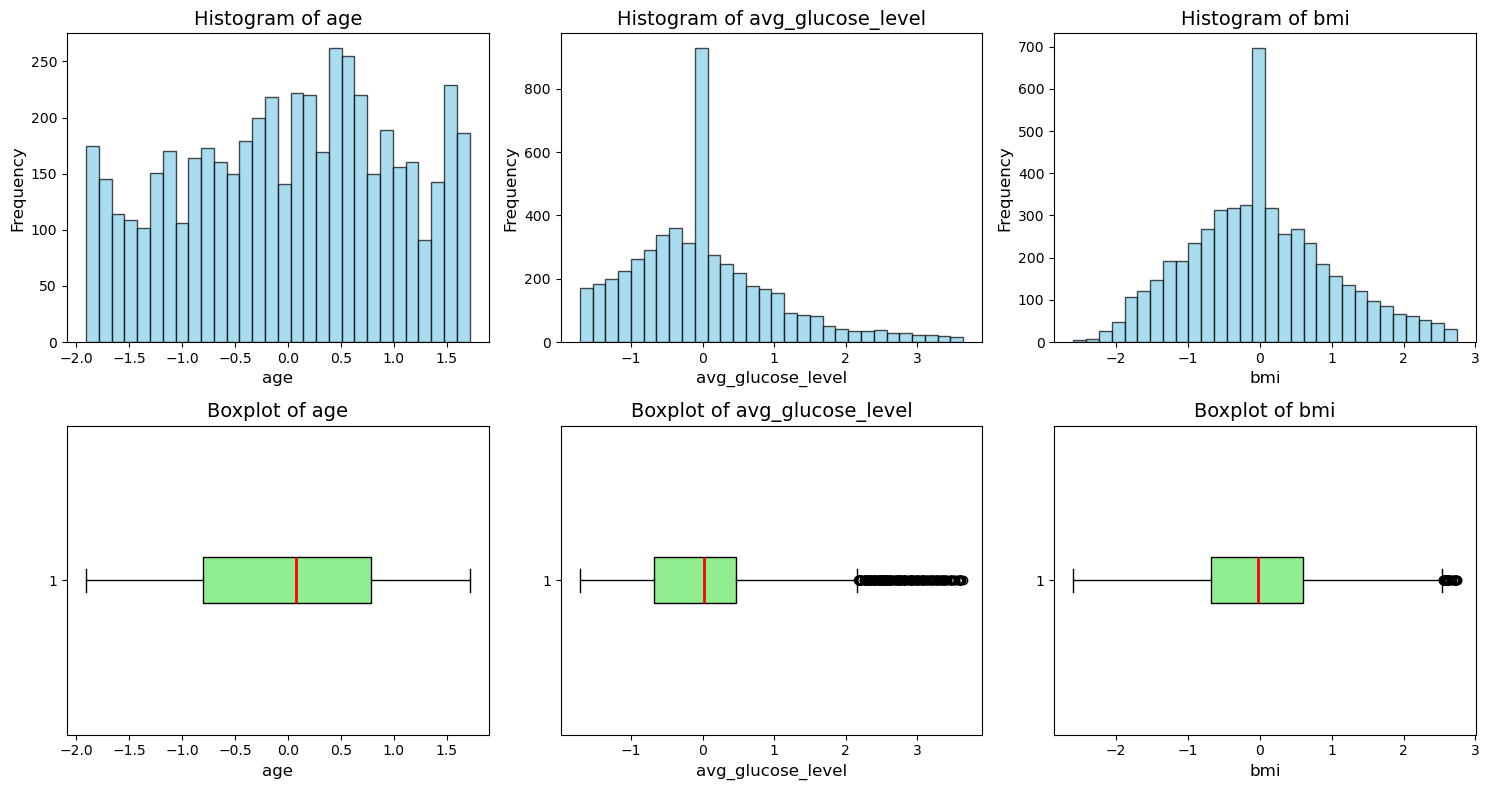

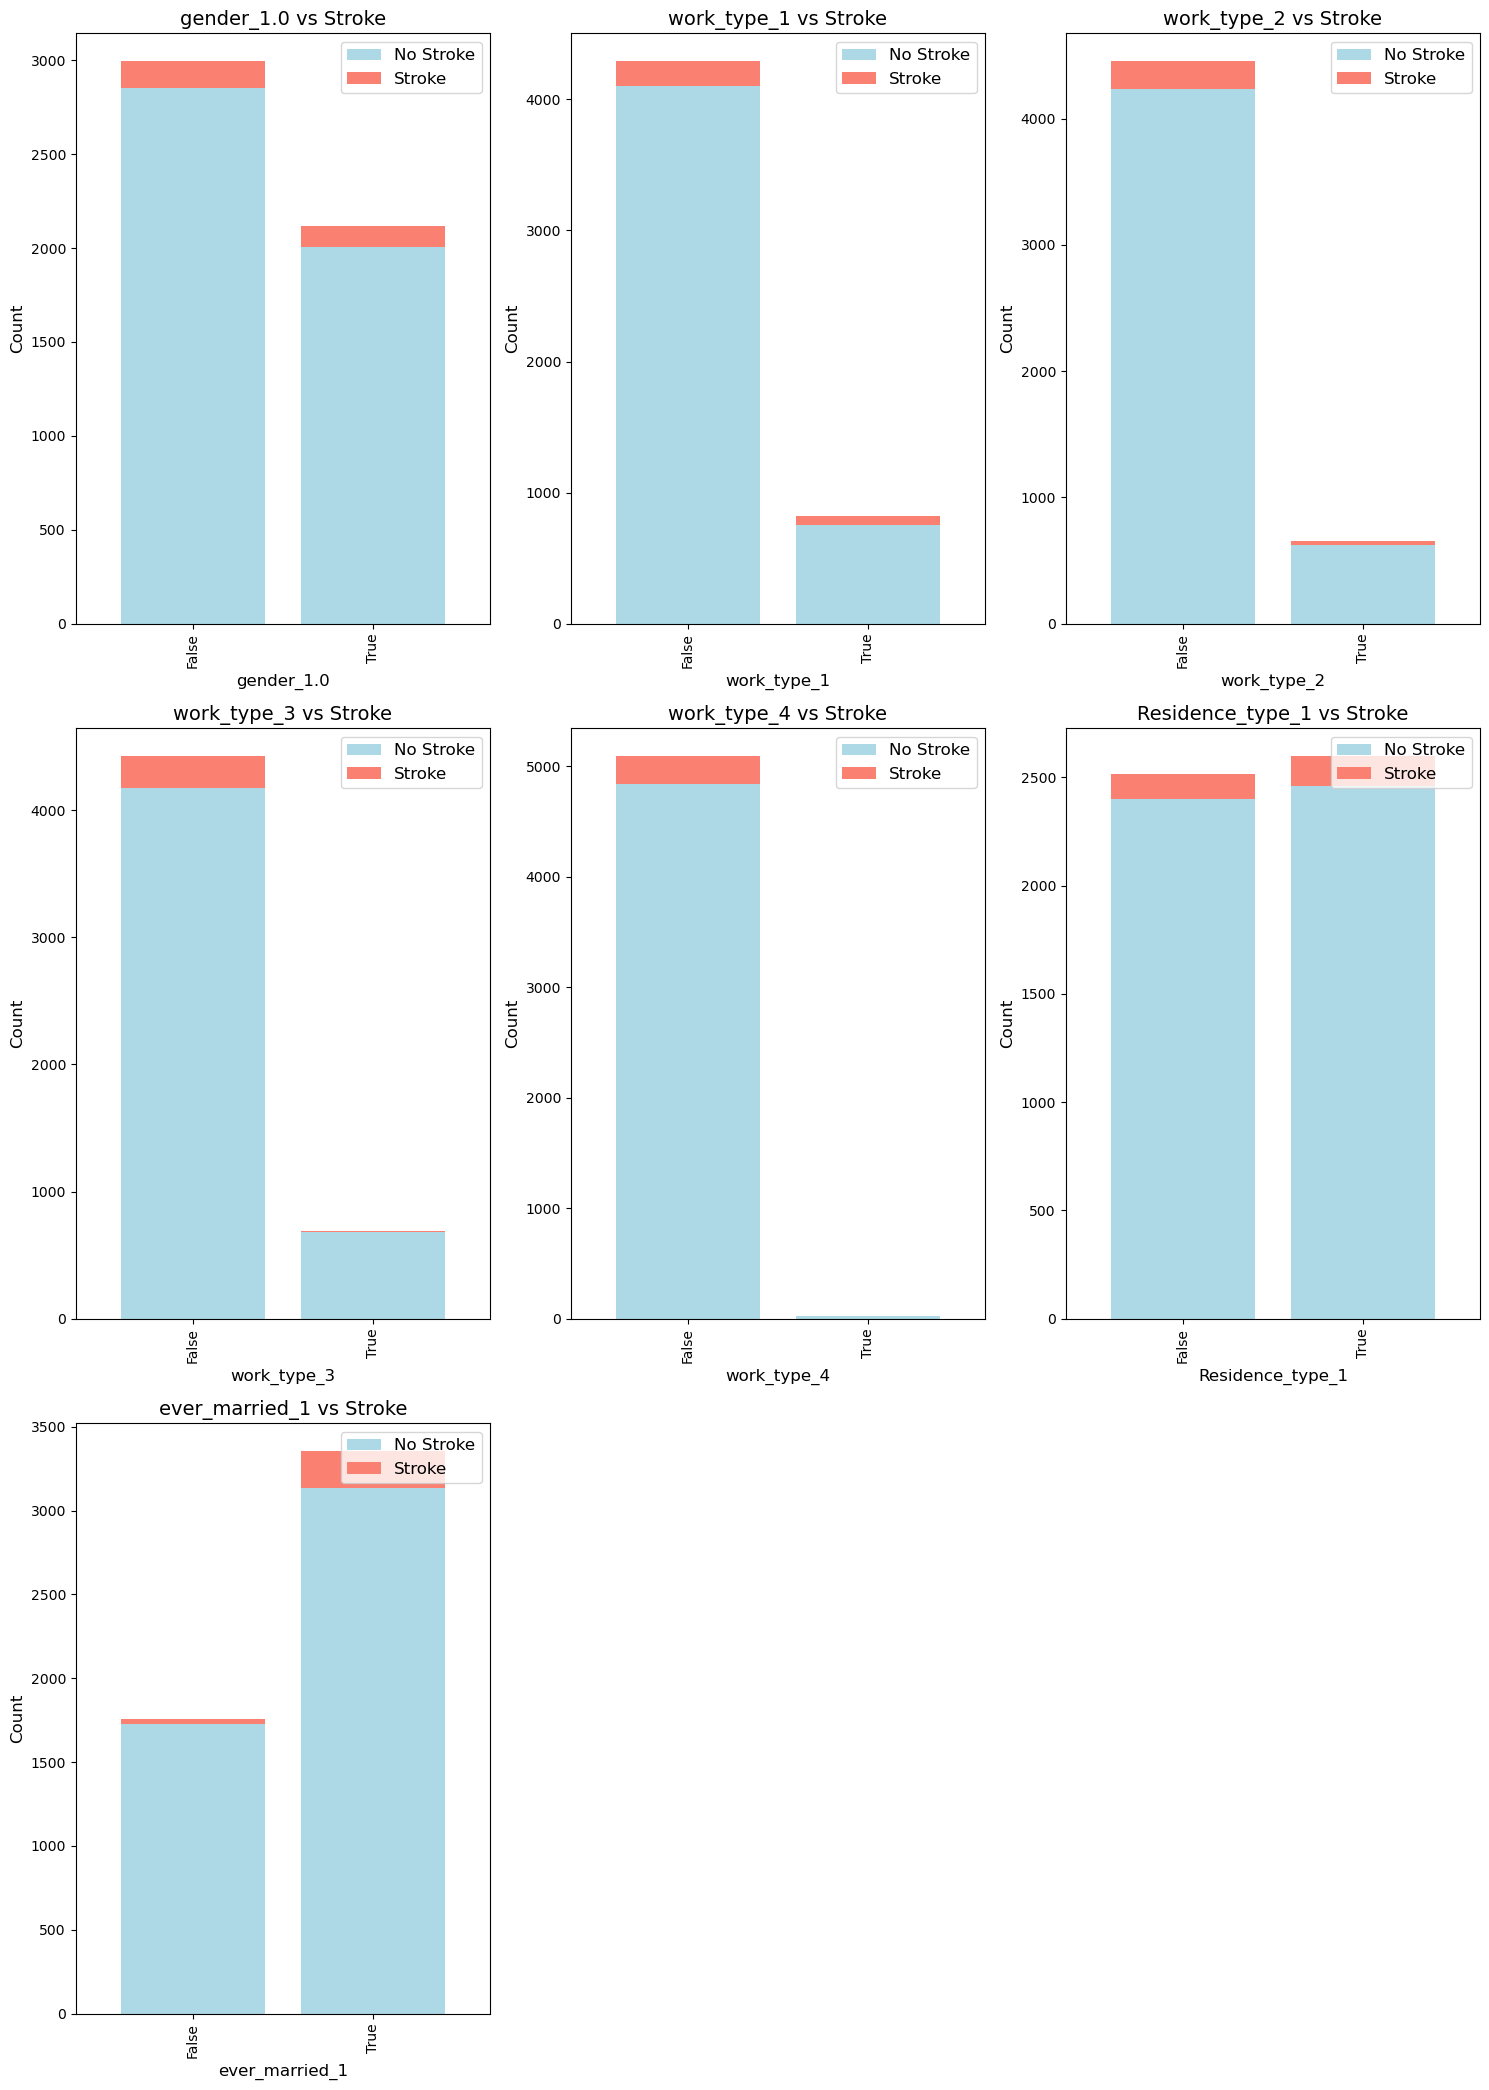

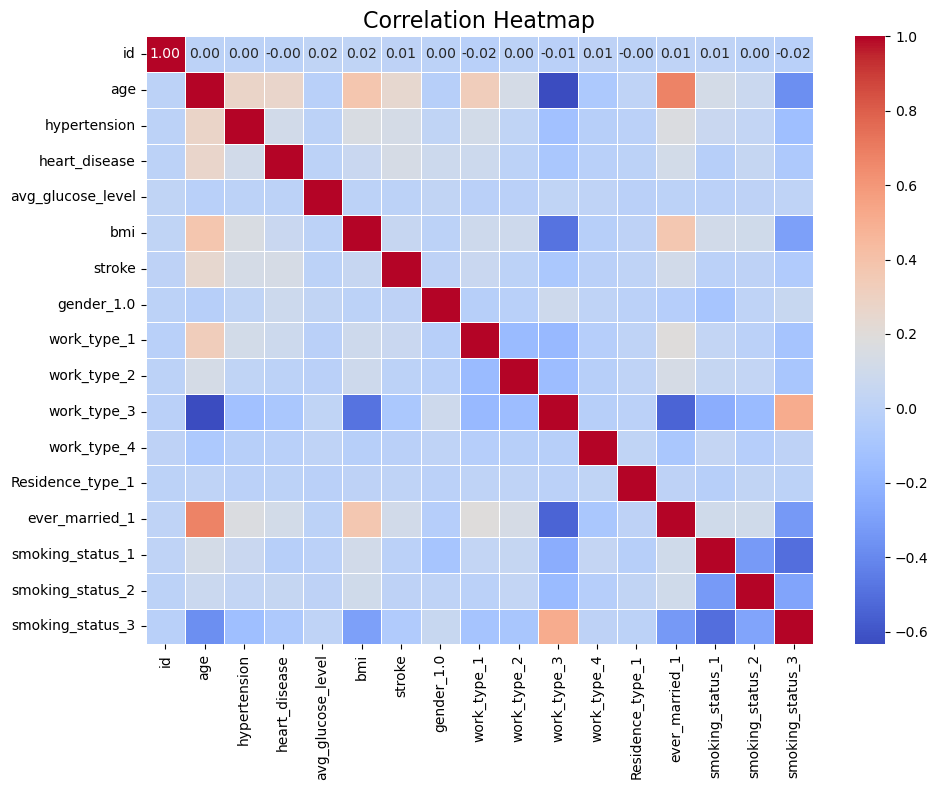

In [70]:
#Ensure no inf values exist in the dataset
stroke_data_encoded.replace([np.inf, -np.inf], np.nan, inplace=True)

#Remove rows with NaN values
stroke_data_encoded.dropna(inplace=True)

#Visualize the distribution of numerical features
numerical_features = ['age', 'avg_glucose_level', 'bmi']
fig, axes = plt.subplots(2, len(numerical_features), figsize=(15, 8))

for i, feature in enumerate(numerical_features):
    axes[0, i].hist(stroke_data_encoded[feature], bins=30, edgecolor='black', color='skyblue', alpha=0.7)
    axes[0, i].set_title(f"Histogram of {feature}", fontsize=14)
    axes[0, i].set_xlabel(feature, fontsize=12)
    axes[0, i].set_ylabel('Frequency', fontsize=12)
    axes[0, i].tick_params(axis='both', labelsize=10)

    axes[1, i].boxplot(stroke_data_encoded[feature], vert=False, patch_artist=True, 
                       boxprops=dict(facecolor='lightgreen', color='black'),
                       medianprops=dict(color='red', linewidth=2))
    axes[1, i].set_title(f"Boxplot of {feature}", fontsize=14)
    axes[1, i].set_xlabel(feature, fontsize=12)
    axes[1, i].tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.show()

#Analyze the relationship between categorical features and the target variable
categorical_features = ['gender_1.0', 'work_type_1', 'work_type_2', 'work_type_3', 'work_type_4', 'Residence_type_1', 'ever_married_1']
fig, axes = plt.subplots(len(categorical_features)//3 + 1, 3, figsize=(15, len(categorical_features) * 3))

#Flatten axes array for easier iteration
axes = axes.flatten()

for i, feature in enumerate(categorical_features):

    stroke_counts = stroke_data_encoded.groupby([feature, 'stroke']).size().unstack().fillna(0)
    
    stroke_counts.plot(kind='bar', stacked=True, ax=axes[i], color=['lightblue', 'salmon'], width=0.8)
    
    axes[i].set_title(f"{feature} vs Stroke", fontsize=14)
    axes[i].set_xlabel(feature, fontsize=12)
    axes[i].set_ylabel('Count', fontsize=12)
    axes[i].tick_params(axis='both', labelsize=10)
    axes[i].legend(["No Stroke", "Stroke"], loc='upper right', fontsize=12)

#Remove any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

#Calculate the correlation matrix
correlation_matrix = stroke_data_encoded.corr()

#Plot the heatmap with improved styling
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, annot_kws={'size': 10})
plt.title("Correlation Heatmap", fontsize=16)
plt.tight_layout()
plt.show()


#The visualizations highlight key patterns related to stroke risk factors. Age distribution peaks among middle-aged 
#individuals, with fewer younger and older participants, while glucose levels exhibit a near-normal distribution and 
#BMI is right-skewed with notable outliers. Females, private-sector workers, married individuals, and urban residents
#show higher stroke rates, suggesting demographic and lifestyle influences. Boxplots indicate that most glucose and 
#BMI values fall within typical ranges, with a few extreme outliers. The correlation heatmap reveals a slight positive
#correlation between stroke and both age and glucose levels, suggesting they increase stroke risk, while BMI shows a 
#negative correlation, indicating a potential link between lower BMI and higher stroke rates. Gender, work type, and 
#marital status also show associations with stroke incidence, providing valuable insights for further analysis or 
#predictive modeling.


## 1.3. Data Splitting (5 Pts)

* Manually split the dataset into training (70%) and testing (30%) sets
* Shuffle and split the data
* Avoid using predefined functions like train_test_split for this task


In [71]:
#Set the random seed for reproducibility
np.random.seed(42)


#shuffle the rows of the dataset
shuffled_data = stroke_data_encoded.sample(frac=1, random_state=42).reset_index(drop=True)

#Determine the split index
train_size = int(0.7 * len(shuffled_data))  
test_size = len(shuffled_data) - train_size  

#Split the data
train_data = shuffled_data[:train_size]
test_data = shuffled_data[train_size:]

#Verify the split by checking the shape
print(f"Training set size: {train_data.shape[0]} rows")
print(f"Testing set size: {test_data.shape[0]} rows")

print("\nSample from Training Set:\n", train_data.head())
print("\nSample from Testing Set:\n", test_data.head())


Training set size: 3576 rows
Testing set size: 1533 rows

Sample from Training Set:
       id       age  hypertension  heart_disease  avg_glucose_level       bmi  \
0  40041 -0.540751             0              0          -1.256654 -0.801738   
1  55244 -0.142705             0              0          -1.235899  0.007838   
2  69824  0.388024             0              0           0.922183  0.267513   
3  38207  1.582163             1              0          -0.700506 -1.336364   
4   8541  1.405253             0              0           0.154708 -0.160187   

   stroke  gender_1.0  work_type_1  work_type_2  work_type_3  work_type_4  \
0       0        True         True        False        False        False   
1       0        True         True        False        False        False   
2       0        True        False        False        False        False   
3       0       False         True        False        False        False   
4       0       False        False         True  

# **PART- 2: Model Building (30 points)**

Implement two classification models:

* k-Nearest Neighbors (kNN)
* Logistic Regression


***You can use scikit-learn***




## 2.1. kNN Classifier (15 Pts)
* Build and train the kNN model
* Choose the optimal k value using Minkowski distance with at least two different values for p


Best kNN Model: k=2, p=2, Accuracy=0.8650


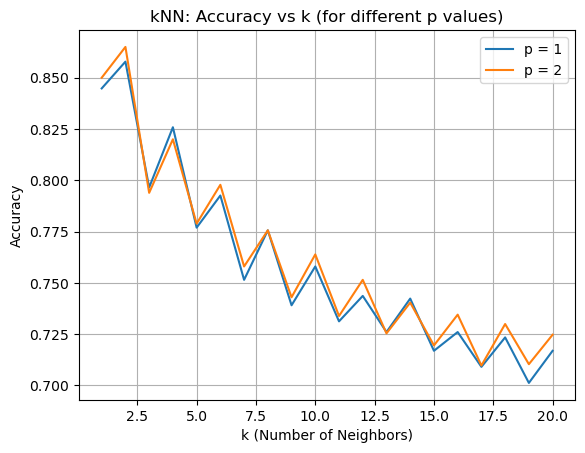


kNN Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.90      0.93      1457
           1       0.12      0.28      0.17        76

    accuracy                           0.86      1533
   macro avg       0.54      0.59      0.55      1533
weighted avg       0.92      0.86      0.89      1533

kNN Accuracy: 0.8649706457925636


In [74]:
#Apply SMOTE to balance the training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

#Function to find optimal k for kNN
def find_optimal_knn(X_train, y_train, X_test, y_test, k_range, p_values):
    best_accuracy = 0
    best_k = 0
    best_p = 0
    accuracies = []

    for p in p_values:
        for k in k_range:
            model = KNeighborsClassifier(n_neighbors=k, p=p)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            accuracy = accuracy_score(y_test, y_pred)
            accuracies.append((k, p, accuracy))
            
            if accuracy > best_accuracy:
                best_accuracy = accuracy
                best_k = k
                best_p = p
                
    return best_k, best_p, best_accuracy, np.array(accuracies)

#Test with different k and p values for kNN
k_range = range(1, 21)
p_values = [1, 2]  # p=1 (Manhattan) and p=2 (Euclidean)
best_k, best_p, best_accuracy, accuracies = find_optimal_knn(X_train_resampled, y_train_resampled, X_test, y_test, k_range, p_values)

#Display the best kNN model result
print(f"Best kNN Model: k={best_k}, p={best_p}, Accuracy={best_accuracy:.4f}")

#Convert accuracies to numpy array for plotting
accuracies = np.array(accuracies)

#Plot the accuracy for different combinations of k and p
for p in p_values:
    subset = accuracies[accuracies[:, 1] == p]
    plt.plot(subset[:, 0], subset[:, 2], label=f'p = {p}')

plt.xlabel('k (Number of Neighbors)')
plt.ylabel('Accuracy')
plt.title('kNN: Accuracy vs k (for different p values)')
plt.legend()
plt.grid(True)
plt.show()

#Train the best kNN model and get predictions
best_knn_model = KNeighborsClassifier(n_neighbors=best_k, p=best_p)
best_knn_model.fit(X_train_resampled, y_train_resampled)
y_pred_knn = best_knn_model.predict(X_test)

#Classification Report and Accuracy for kNN
print("\nkNN Classification Report:")
print(classification_report(y_test, y_pred_knn))
print("kNN Accuracy:", accuracy_score(y_test, y_pred_knn))


## 2.2. Logistic Regression (15 Pts)
* Build and train the Logistic Regression model

In [75]:
#Logistic Regression model
logreg = LogisticRegression(class_weight='balanced')
logreg.fit(X_train, y_train)

#Evaluate the model on the test set
y_pred_logreg = logreg.predict(X_test)

print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_logreg))
print("Accuracy:", accuracy_score(y_test, y_pred_logreg))


Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.76      0.86      1457
           1       0.15      0.79      0.25        76

    accuracy                           0.76      1533
   macro avg       0.57      0.77      0.55      1533
weighted avg       0.94      0.76      0.83      1533

Accuracy: 0.7619047619047619



# **PART- 3: Model Evaluation (35 points)**



## 3.1 Confusion Matrix (15)

Analysis of the confusion matrices for both models:

* Plot and interpret the confusion matrices
* Display accuracy, precision, recall, and F1-score for both models



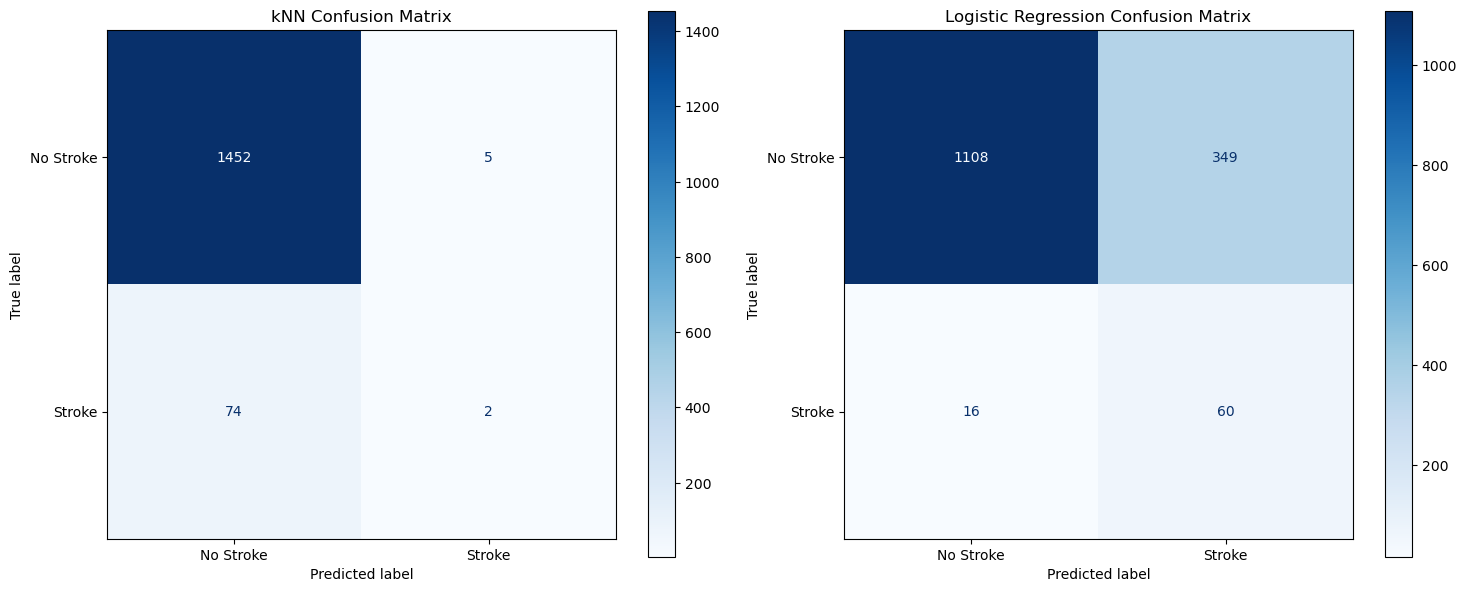

kNN Model Metrics:
Accuracy: 0.9485
Precision: 0.2857
Recall: 0.0263
F1-Score: 0.0482

Logistic Regression Model Metrics:
Accuracy: 0.7619
Precision: 0.1467
Recall: 0.7895
F1-Score: 0.2474


In [78]:
#kNN Model predictions
y_pred_knn = KNeighborsClassifier(n_neighbors=2, p=2).fit(X_train, y_train).predict(X_test)

#Logistic Regression Model predictions
y_pred_logreg = logreg.predict(X_test)


# Confusion Matrices for both models
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)
conf_matrix_logreg = confusion_matrix(y_test, y_pred_logreg)

#Plot Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

#kNN Confusion Matrix
disp_knn = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_knn, display_labels=["No Stroke", "Stroke"])
disp_knn.plot(cmap='Blues', ax=axes[0])
axes[0].set_title("kNN Confusion Matrix")

#Logistic Regression Confusion Matrix
disp_logreg = ConfusionMatrixDisplay(confusion_matrix=conf_matrix_logreg, display_labels=["No Stroke", "Stroke"])
disp_logreg.plot(cmap='Blues', ax=axes[1])
axes[1].set_title("Logistic Regression Confusion Matrix")

plt.tight_layout()
plt.show()

#Display metrics (accuracy, precision, recall, f1-score) for both models

#kNN Metrics
accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)

#Logistic Regression Metrics
accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
precision_logreg = precision_score(y_test, y_pred_logreg)
recall_logreg = recall_score(y_test, y_pred_logreg)
f1_logreg = f1_score(y_test, y_pred_logreg)

print(f"kNN Model Metrics:")
print(f"Accuracy: {accuracy_knn:.4f}")
print(f"Precision: {precision_knn:.4f}")
print(f"Recall: {recall_knn:.4f}")
print(f"F1-Score: {f1_knn:.4f}")

print(f"\nLogistic Regression Model Metrics:")
print(f"Accuracy: {accuracy_logreg:.4f}")
print(f"Precision: {precision_logreg:.4f}")
print(f"Recall: {recall_logreg:.4f}")
print(f"F1-Score: {f1_logreg:.4f}")

## 3.2 Precision-Recall Curves (5)

Evaluate the Precision-Recall curves for both models:

* Plot and analyze the curves

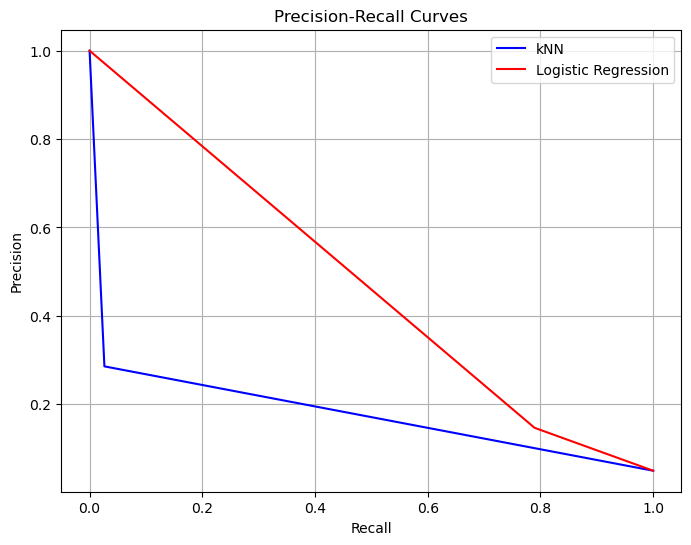

In [79]:
#kNN Precision-Recall Curve
precision_knn, recall_knn, _ = precision_recall_curve(y_test, y_pred_knn)
#Logistic Regression Precision-Recall Curve
precision_logreg, recall_logreg, _ = precision_recall_curve(y_test, y_pred_logreg)

#Plot Precision-Recall curves
plt.figure(figsize=(8, 6))
plt.plot(recall_knn, precision_knn, label="kNN", color='b')
plt.plot(recall_logreg, precision_logreg, label="Logistic Regression", color='r')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curves')
plt.legend()
plt.grid(True)
plt.show()


## 3.3. Compare the Model (15 Pts)

Prepare a detailed evaluation report with metrics, visualizations, and comparative analysis.

* Compare the performance of kNN and Logistic Regression based on the metrics.

* Discuss which model performs better and hypothesize why.

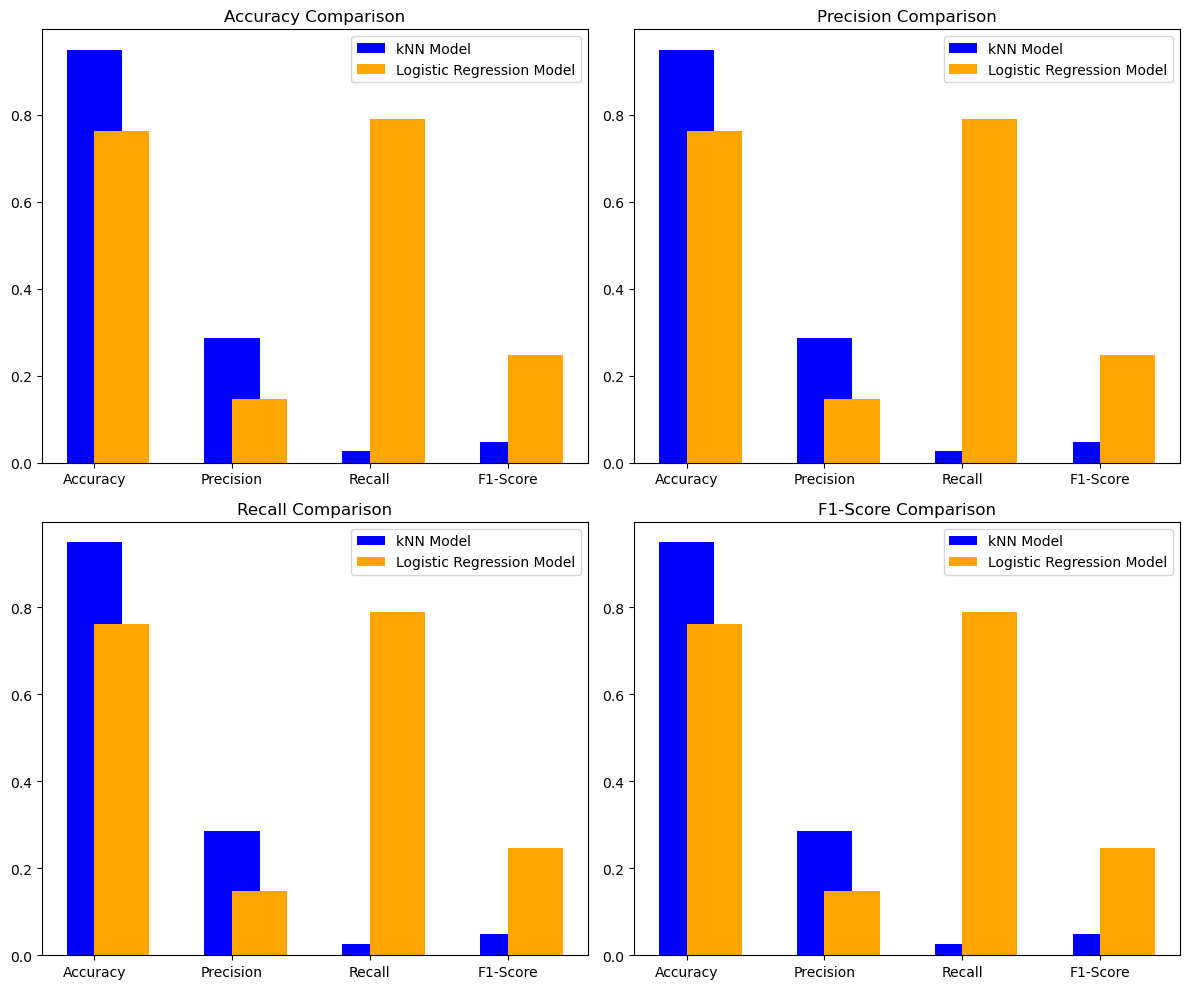

In [81]:
#Metrics Summary as a DataFrame
metrics_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'kNN Model': [0.9485, 0.2857, 0.0263, 0.0482],
    'Logistic Regression Model': [0.7619, 0.1467, 0.7895, 0.2474]
}

metrics_df = pd.DataFrame(metrics_data)

metrics_df

#Visualizing the comparison of performance metrics
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

#Plotting Accuracy Comparison
axes[0, 0].bar(metrics_df['Metric'], metrics_df['kNN Model'], width=0.4, label='kNN Model', color='blue', align='center')
axes[0, 0].bar(metrics_df['Metric'], metrics_df['Logistic Regression Model'], width=0.4, label='Logistic Regression Model', color='orange', align='edge')
axes[0, 0].set_title('Accuracy Comparison')
axes[0, 0].legend()

#Plotting Precision Comparison
axes[0, 1].bar(metrics_df['Metric'], metrics_df['kNN Model'], width=0.4, label='kNN Model', color='blue', align='center')
axes[0, 1].bar(metrics_df['Metric'], metrics_df['Logistic Regression Model'], width=0.4, label='Logistic Regression Model', color='orange', align='edge')
axes[0, 1].set_title('Precision Comparison')
axes[0, 1].legend()

#Plotting Recall Comparison
axes[1, 0].bar(metrics_df['Metric'], metrics_df['kNN Model'], width=0.4, label='kNN Model', color='blue', align='center')
axes[1, 0].bar(metrics_df['Metric'], metrics_df['Logistic Regression Model'], width=0.4, label='Logistic Regression Model', color='orange', align='edge')
axes[1, 0].set_title('Recall Comparison')
axes[1, 0].legend()

#Plotting F1-Score Comparison
axes[1, 1].bar(metrics_df['Metric'], metrics_df['kNN Model'], width=0.4, label='kNN Model', color='blue', align='center')
axes[1, 1].bar(metrics_df['Metric'], metrics_df['Logistic Regression Model'], width=0.4, label='Logistic Regression Model', color='orange', align='edge')
axes[1, 1].set_title('F1-Score Comparison')
axes[1, 1].legend()

# Show the plots
plt.tight_layout()
plt.show()


### Comparative Analysis of kNN and Logistic Regression Models
# 
# The key performance metrics for both models indicate significant differences, especially when considering the 
# healthcare context where stroke detection is critical.
# 
# Accuracy: The kNN model achieves an accuracy of 94.85%, primarily due to its success in predicting the majority 
# class (No Stroke). However, this metric is misleading in the context of imbalanced datasets. Logistic Regression, 
# with an accuracy of 76.19%, underperforms in comparison, but this metric alone doesn't represent the model's ability 
# to detect the minority class.
# 
# Precision: The kNN model achieves a precision of 0.2857, correctly identifying 28.57% of the "No Stroke" instances. 
# However, it fails to identify stroke cases effectively, as seen from the very low recall. On the other hand, Logistic
# Regression has a precision of 0.1467, indicating that it struggles with false positives, but it still identifies a 
# larger proportion of stroke cases than kNN.
# 
# Recall: The recall for kNN is alarmingly low at 2.63%, meaning that it rarely identifies stroke cases correctly. 
# In contrast, Logistic Regression has a recall of 78.95%, indicating that it performs far better at identifying true
# stroke cases, which is crucial in healthcare applications where undetected stroke cases could lead to serious 
# consequences.
# 
# F1-Score: The kNN model has a very low F1-score of 0.0482, indicating poor balance between precision and recall. 
# Logistic Regression, although still needing improvement, has a significantly better F1-score of 0.2474, reflecting 
# its ability to strike a better balance in detecting stroke cases.
# 
# Conclusion:
# While the kNN model has higher overall accuracy, this is largely driven by its ability to correctly classify 
# non-stroke instances, leading to a high number of true negatives. Its inability to correctly identify stroke cases 
# (low recall and F1-score) makes it unsuitable for detecting the minority class. On the other hand, Logistic Regression
# despite its lower accuracy, excels in recall, making it more suitable for healthcare applications where the priority 
# is to identify as many stroke cases as possible.
# 
# Therefore, Logistic Regression is the better model for this dataset, especially in the context of stroke prediction. 
# Its higher recall and more balanced precision-recall trade-off make it the preferred choice for detecting stroke
# cases, where false negatives (undetected strokes) have severe implications. kNN's bias towards the majority class 
# leads to poor performance in detecting stroke cases, making it less effective for this specific task.


# SUBMIT FORMAT

* **<-zip>**
  - **studentID_name_surname_hw4.ipynb**


# PLAGIARISM

All work on assignments must be done individually. You are encouraged to discuss the given assignments with your classmates, but these discussions should be carried out in an abstract way. That is, discussions related to a particular solution to a specific probem (either in actual code or in pseudocode) will not be tolerated. In short, turning in someone else’s work (including work available on the internet), in whole or in part, as your own will be considered as a violation of academic integrity. Please note that the former conditions also hold for the material attained using AI tools, including ChatGPT, GitHub Copilot, etc.